In [5]:
from ax.service.ax_client import AxClient
import ax
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
experiment_folder = '2026-02-19'
iteration = 6

optimizer_path = f'../{experiment_folder}/optimizer/optimizer_{iteration}_loaded.json'
params_path = f'../{experiment_folder}/experiment_parameters.csv'

In [7]:
# experiment_folder = 'smoketest_output'
# iteration = 7

# optimizer_path = f'../{experiment_folder}/optimizer/optimizer_smoketest_{iteration}_loaded.json'
# params_path = f'../{experiment_folder}/experiment_parameters_smoketest.csv'

In [8]:
# import the optimizer
# Corrected code to load the optimizer
ax_client = AxClient.load_from_json_file(optimizer_path)

/Users/zeqing/opt/anaconda3/envs/drug-surfactant/lib/python3.10/site-packages/ax/storage/json_store/decoder.py:303: AxParameterWarning: `sort_values` is not specified for `ChoiceParameter` "drug". Defaulting to `False` for parameters of `ParameterType` STRING. To override this behavior (or avoid this warning), specify `sort_values` during `ChoiceParameter` construction.
  return _class(
[INFO 02-20 06:28:30] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.


In [9]:
# Get the experiment data in DataFrame format
df = ax_client.get_trials_data_frame()
df

[WARNING 02-20 06:28:30] ax.service.utils.report_utils: Column reason missing for all trials. Not appending column.


,trial_index,arm_name,trial_status,generation_method,is_feasible,absorbance,obj_total_vol,s1,s2,s3,s4,s5,s6,s7,s8,drug
0,0,0_0,COMPLETED,Manual,True,0.0350,790.0,0.0,0.0,0.0,0.0,620.0,0.0,170.0,0.0,IBP
1,1,1_0,COMPLETED,Manual,True,0.0360,1035.0,0.0,0.0,640.0,0.0,0.0,0.0,0.0,395.0,IBP
2,2,2_0,COMPLETED,Manual,True,0.0370,825.0,0.0,0.0,185.0,0.0,640.0,0.0,0.0,0.0,IBP
3,3,3_0,COMPLETED,Manual,False,2.4125,760.0,0.0,415.0,0.0,345.0,0.0,0.0,0.0,0.0,IBP
4,4,4_0,COMPLETED,Manual,True,0.0335,1065.0,750.0,0.0,0.0,0.0,0.0,315.0,0.0,0.0,IBP
5,5,5_0,COMPLETED,Manual,True,0.0345,780.0,0.0,360.0,420.0,0.0,0.0,0.0,0.0,0.0,IBP
6,6,6_0,COMPLETED,Manual,True,0.0350,900.0,60.0,0.0,0.0,840.0,0.0,0.0,0.0,0.0,IBP
7,7,7_0,COMPLETED,Manual,True,0.0345,585.0,85.0,0.0,500.0,0.0,0.0,0.0,0.0,0.0,IBP
8,8,8_0,COMPLETED,Manual,True,0.0345,725.0,290.0,435.0,0.0,0.0,0.0,0.0,0.0,0.0,IBP
9,9,9_0,COMPLETED,Manual,True,0.0350,450.0,145.0,305.0,0.0,0.0,0.0,0.0,0.0,0.0,IBP


In [10]:
exp_params = pd.read_csv(params_path)
exp_params_dict = dict(zip(exp_params.iloc[:, 0], exp_params.iloc[:, 1]))

exp_params_dict

{'NUM_ITERATIONS': '11',
 'TRIALS_PER_ITERATION': '3',
 'REPLICATES': '2',
 'SURFACTANT_VOL_REDUCTION (%)': '10.0',
 'DRUG_CHOICES': 'IBP',
 'ABSORBANCE_THRESHOLD': '0.06',
 'NUM_RANDOM_TRIALS': '9',
 'PUNISHMENT_FACTOR': '1',
 'DELAY_TIME': '60',
 'GREEDY_HIGH_ITERS': '4',
 'GREEDY_MEDIUM_ITERS': '4',
 'GREEDY_LOW_ITERS': '2'}

In [11]:
def add_iteration_number(df, trials_per_iteration, num_random_trials):
    df = df.copy()
    df['iteration'] = 0
    mask = df['trial_index'] >= num_random_trials
    df.loc[mask, 'iteration'] = ((df.loc[mask, 'trial_index'] - num_random_trials) // trials_per_iteration) + 1
    return df

In [12]:
df = add_iteration_number(df, int(exp_params_dict['TRIALS_PER_ITERATION']), int(exp_params_dict['NUM_RANDOM_TRIALS']))
df

,trial_index,arm_name,trial_status,generation_method,is_feasible,absorbance,obj_total_vol,s1,s2,s3,s4,s5,s6,s7,s8,drug,iteration
0,0,0_0,COMPLETED,Manual,True,0.0350,790.0,0.0,0.0,0.0,0.0,620.0,0.0,170.0,0.0,IBP,0
1,1,1_0,COMPLETED,Manual,True,0.0360,1035.0,0.0,0.0,640.0,0.0,0.0,0.0,0.0,395.0,IBP,0
2,2,2_0,COMPLETED,Manual,True,0.0370,825.0,0.0,0.0,185.0,0.0,640.0,0.0,0.0,0.0,IBP,0
3,3,3_0,COMPLETED,Manual,False,2.4125,760.0,0.0,415.0,0.0,345.0,0.0,0.0,0.0,0.0,IBP,0
4,4,4_0,COMPLETED,Manual,True,0.0335,1065.0,750.0,0.0,0.0,0.0,0.0,315.0,0.0,0.0,IBP,0
5,5,5_0,COMPLETED,Manual,True,0.0345,780.0,0.0,360.0,420.0,0.0,0.0,0.0,0.0,0.0,IBP,0
6,6,6_0,COMPLETED,Manual,True,0.0350,900.0,60.0,0.0,0.0,840.0,0.0,0.0,0.0,0.0,IBP,0
7,7,7_0,COMPLETED,Manual,True,0.0345,585.0,85.0,0.0,500.0,0.0,0.0,0.0,0.0,0.0,IBP,0
8,8,8_0,COMPLETED,Manual,True,0.0345,725.0,290.0,435.0,0.0,0.0,0.0,0.0,0.0,0.0,IBP,0
9,9,9_0,COMPLETED,Manual,True,0.0350,450.0,145.0,305.0,0.0,0.0,0.0,0.0,0.0,0.0,IBP,1


In [13]:
def add_success_column(df, threshold):
    df = df.copy()
    df['success'] = (df['absorbance'] < threshold).astype(int)
    return df

In [14]:
df = add_success_column(df, float(exp_params_dict['ABSORBANCE_THRESHOLD']))
df

,trial_index,arm_name,trial_status,generation_method,is_feasible,absorbance,obj_total_vol,s1,s2,s3,s4,s5,s6,s7,s8,drug,iteration,success
0,0,0_0,COMPLETED,Manual,True,0.0350,790.0,0.0,0.0,0.0,0.0,620.0,0.0,170.0,0.0,IBP,0,1
1,1,1_0,COMPLETED,Manual,True,0.0360,1035.0,0.0,0.0,640.0,0.0,0.0,0.0,0.0,395.0,IBP,0,1
2,2,2_0,COMPLETED,Manual,True,0.0370,825.0,0.0,0.0,185.0,0.0,640.0,0.0,0.0,0.0,IBP,0,1
3,3,3_0,COMPLETED,Manual,False,2.4125,760.0,0.0,415.0,0.0,345.0,0.0,0.0,0.0,0.0,IBP,0,0
4,4,4_0,COMPLETED,Manual,True,0.0335,1065.0,750.0,0.0,0.0,0.0,0.0,315.0,0.0,0.0,IBP,0,1
5,5,5_0,COMPLETED,Manual,True,0.0345,780.0,0.0,360.0,420.0,0.0,0.0,0.0,0.0,0.0,IBP,0,1
6,6,6_0,COMPLETED,Manual,True,0.0350,900.0,60.0,0.0,0.0,840.0,0.0,0.0,0.0,0.0,IBP,0,1
7,7,7_0,COMPLETED,Manual,True,0.0345,585.0,85.0,0.0,500.0,0.0,0.0,0.0,0.0,0.0,IBP,0,1
8,8,8_0,COMPLETED,Manual,True,0.0345,725.0,290.0,435.0,0.0,0.0,0.0,0.0,0.0,0.0,IBP,0,1
9,9,9_0,COMPLETED,Manual,True,0.0350,450.0,145.0,305.0,0.0,0.0,0.0,0.0,0.0,0.0,IBP,1,1


In [15]:
def plot_surfactant_combined(df, success_only=False, transparent=False):
    from matplotlib.patches import Polygon
    import matplotlib.gridspec as gridspec

    surfactants = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']
    palette = [
        '#4878CF', '#6ACC65', "#F36D6D", '#B47CC7',
        '#C4AD66', '#77BEDB', '#E68310', "#911828"
    ]

    # Always use full df for best-so-far; success_only only affects stacked bars & bubble
    all_iters   = sorted(df['iteration'].unique())
    data        = df[df['success'] == 1] if success_only else df
    iters       = list(all_iters)
    n_iter      = len(iters)
    grouped     = data.groupby('iteration')[surfactants].mean().reindex(all_iters)

    region_defs = [
        (0, 0,           '#888888', 'Random'),
        (1, 4,           '#3A7DC9', 'High Greedy'),
        (5, 8,           '#2A9D5C', 'Medium Greedy'),
        (9, max(iters),  '#C05046', 'Low Greedy'),
    ]

    # ── Best-so-far computation (always from full df, success==1) ──────
    successful       = df[df['success'] == 1]
    iter_best        = successful.groupby('iteration')['obj_total_vol'].min()
    iter_best_full   = iter_best.reindex(all_iters)
    best_so_far      = iter_best_full.cummin().ffill()

    rc = {
        'font.family': 'DejaVu Sans', 'font.size': 11,
        'axes.linewidth': 0.8,
        'axes.spines.top': False, 'axes.spines.right': False,
        'xtick.direction': 'out', 'ytick.direction': 'out',
        'xtick.major.size': 4, 'ytick.major.size': 4,
        'legend.frameon': True, 'legend.framealpha': 0.9,
        'legend.edgecolor': '#cccccc',
    }

    bar_w = 0.55

    def get_region_x_bounds(lo, hi):
        xs = [x for x in iters if lo <= x <= hi]
        if not xs:
            return None
        return min(xs) - bar_w / 2 - 0.1, max(xs) + bar_w / 2 + 0.1

    def draw_region_shading(ax):
        for lo, hi, color, label in region_defs:
            bounds = get_region_x_bounds(lo, hi)
            if bounds is None:
                continue
            x0, x1 = bounds
            ax.axvspan(x0, x1, color=color, alpha=0.06, zorder=0, linewidth=0)

    def sep_lines(ax):
        for sx in [0.5, 4.5, 8.5]:
            if min(iters) < sx < max(iters):
                ax.axvline(sx, color='#444444', lw=1.0,
                           linestyle='--', dashes=(5, 3), zorder=4, alpha=0.5)

    def region_labels(ax, y_bracket, y_text):
        for lo, hi, color, label in region_defs:
            xs = [x for x in iters if lo <= x <= hi]
            if not xs:
                continue
            ax.annotate('', xy=(max(xs) + 0.45, y_bracket),
                        xytext=(min(xs) - 0.45, y_bracket),
                        arrowprops=dict(arrowstyle='-', color=color, lw=1.4))
            ax.text((min(xs) + max(xs)) / 2, y_text, label,
                    ha='center', va='bottom', fontsize=9,
                    color=color, fontweight='semibold')

    with plt.rc_context(rc):
        fig = plt.figure(figsize=(20, 13),
                         facecolor='none' if transparent else 'white')
        gs = gridspec.GridSpec(3, 2,
                               height_ratios=[1, 1, 1],
                               width_ratios=[1, 0.13],
                               hspace=0.25, wspace=0.04)
        ax_best = fig.add_subplot(gs[1, 0])
        ax_top  = fig.add_subplot(gs[0, 0], sharex=ax_best)
        ax_bot  = fig.add_subplot(gs[2, 0], sharex=ax_best)
        ax_leg  = fig.add_subplot(gs[:, 1])
        ax_leg.axis('off')

        if transparent:
            for ax in [ax_best, ax_top, ax_bot]:
                ax.set_facecolor('none')

        x_lo = min(iters) - bar_w
        x_hi = max(iters) + bar_w

        # ══ BEST-SO-FAR ════════════════════════════════════════════════
        draw_region_shading(ax_best)

        valid_bsf = best_so_far.dropna()
        ax_best.step(valid_bsf.index, valid_bsf.values,
                     where='post', color='#C05046', lw=2.0,
                     zorder=5, label='Best so far')
        ax_best.fill_between(valid_bsf.index, valid_bsf.values,
                             valid_bsf.values.max() * 1.00,
                             step='post', color='#C05046', alpha=0.08, zorder=0)

        bsf_min = valid_bsf.min() if len(valid_bsf) else 0
        bsf_max = valid_bsf.max() if len(valid_bsf) else 1
        pad = (bsf_max - bsf_min) * 0.25 if bsf_max > bsf_min else 1
        ax_best.set_ylim(max(0, bsf_min - pad), bsf_max + pad * 1.5)
        ax_best.set_xlim(x_lo, x_hi)
        ax_best.set_ylabel('Best obj_total_vol\n(µL)', fontsize=11, labelpad=6)
        ax_best.yaxis.grid(True, color='#e0e0e0', linewidth=0.6, zorder=1)
        ax_best.set_axisbelow(True)
        sep_lines(ax_best)
        plt.setp(ax_best.get_xticklabels(), visible=False)

        # ══ STACKED BARS ═══════════════════════════════════════════════
        cum = np.zeros(n_iter)
        bar_bottoms, bar_tops = [], []
        for s in surfactants:
            bar_bottoms.append(cum.copy())
            cum = cum + grouped[s].values
            bar_tops.append(cum.copy())

        y_max = bar_tops[-1].max()
        draw_region_shading(ax_top)

        for j, s in enumerate(surfactants):
            color = palette[j]
            for i in range(n_iter - 1):
                xl = iters[i]   + bar_w / 2
                xr = iters[i+1] - bar_w / 2
                poly = Polygon(list(zip(
                    [xl, xr, xr, xl],
                    [bar_tops[j][i],      bar_tops[j][i+1],
                     bar_bottoms[j][i+1], bar_bottoms[j][i]]
                )), closed=True, facecolor=color, alpha=0.18, linewidth=0)
                ax_top.add_patch(poly)
                ax_top.plot([xl, xr], [bar_tops[j][i],     bar_tops[j][i+1]],
                            color=color, lw=0.7, alpha=0.55, zorder=2)
                ax_top.plot([xl, xr], [bar_bottoms[j][i],  bar_bottoms[j][i+1]],
                            color=color, lw=0.7, alpha=0.55, zorder=2)

        for j, s in enumerate(surfactants):
            ax_top.bar(iters, grouped[s].values, width=bar_w,
                       bottom=bar_bottoms[j], color=palette[j],
                       alpha=0.88, linewidth=0.4, edgecolor='white',
                       label=s, zorder=3)

        ax_top.set_ylim(0, y_max * 1.28)
        ax_top.set_xlim(x_lo, x_hi)
        ax_top.set_ylabel('Mean Concentration (µL)', fontsize=11, labelpad=6)
        ax_top.yaxis.grid(True, color='#e0e0e0', linewidth=0.6, zorder=1)
        ax_top.set_axisbelow(True)
        sep_lines(ax_top)
        region_labels(ax_top, y_max * 1.12, y_max * 1.17)
        plt.setp(ax_top.get_xticklabels(), visible=False)

        handles, labels_leg = ax_top.get_legend_handles_labels()
        ax_top.legend(handles[::-1], labels_leg[::-1],
                      title='Surfactant', title_fontsize=14,
                      fontsize=12, loc='upper left',
                      bbox_to_anchor=(1.02, 1),
                      borderaxespad=0, handlelength=1.2,
                      frameon=True, framealpha=0., edgecolor='#cccccc')

        # ══ BUBBLE GRID ════════════════════════════════════════════════
        n_surf   = len(surfactants)
        max_val  = grouped.values.max()
        max_area = 1600

        def to_area(v):
            return (v / max_val) * max_area if max_val > 0 else max_area * 0.5

        draw_region_shading(ax_bot)

        for i in range(n_surf):
            if i % 2 == 0:
                ax_bot.axhspan(i - 0.5, i + 0.5,
                               color='#000000', alpha=0.03, zorder=0)
        for it in iters:
            ax_bot.axvline(it, color='#e0e0e0', lw=0.6, zorder=1)

        for j, s in enumerate(surfactants):
            for it in iters:
                val = grouped.loc[it, s]
                if pd.notna(val):
                    ax_bot.scatter(it, j, s=to_area(val),
                                   c=palette[j], alpha=0.82,
                                   edgecolors='white', linewidths=0.6, zorder=3)

        sep_lines(ax_bot)
        ax_bot.set_ylim(-0.7, n_surf - 0.5)
        ax_bot.set_xlim(x_lo, x_hi)
        ax_bot.set_yticks(range(n_surf))
        ax_bot.set_yticklabels(surfactants, fontsize=10)
        ax_bot.set_xticks(iters)
        ax_bot.set_xticklabels([str(int(it)) for it in iters], fontsize=10)
        ax_bot.set_xlabel('Iteration', fontsize=11, labelpad=6)
        ax_bot.set_ylabel('Surfactant', fontsize=11, labelpad=6)

        # ── Panel labels ───────────────────────────────────────────────
        for ax, label in [(ax_top, 'a)'), (ax_best, 'b)'), (ax_bot, 'c)')]:
            ax.text(-0.020, 1.04, label, transform=ax.transAxes,
                    fontsize=12, va='bottom', ha='left')

        fig.tight_layout()
        plt.show()


/var/folders/hk/7jjnrbrj53n1t8_bmkhf0_k00000gn/T/ipykernel_49779/2035733840.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


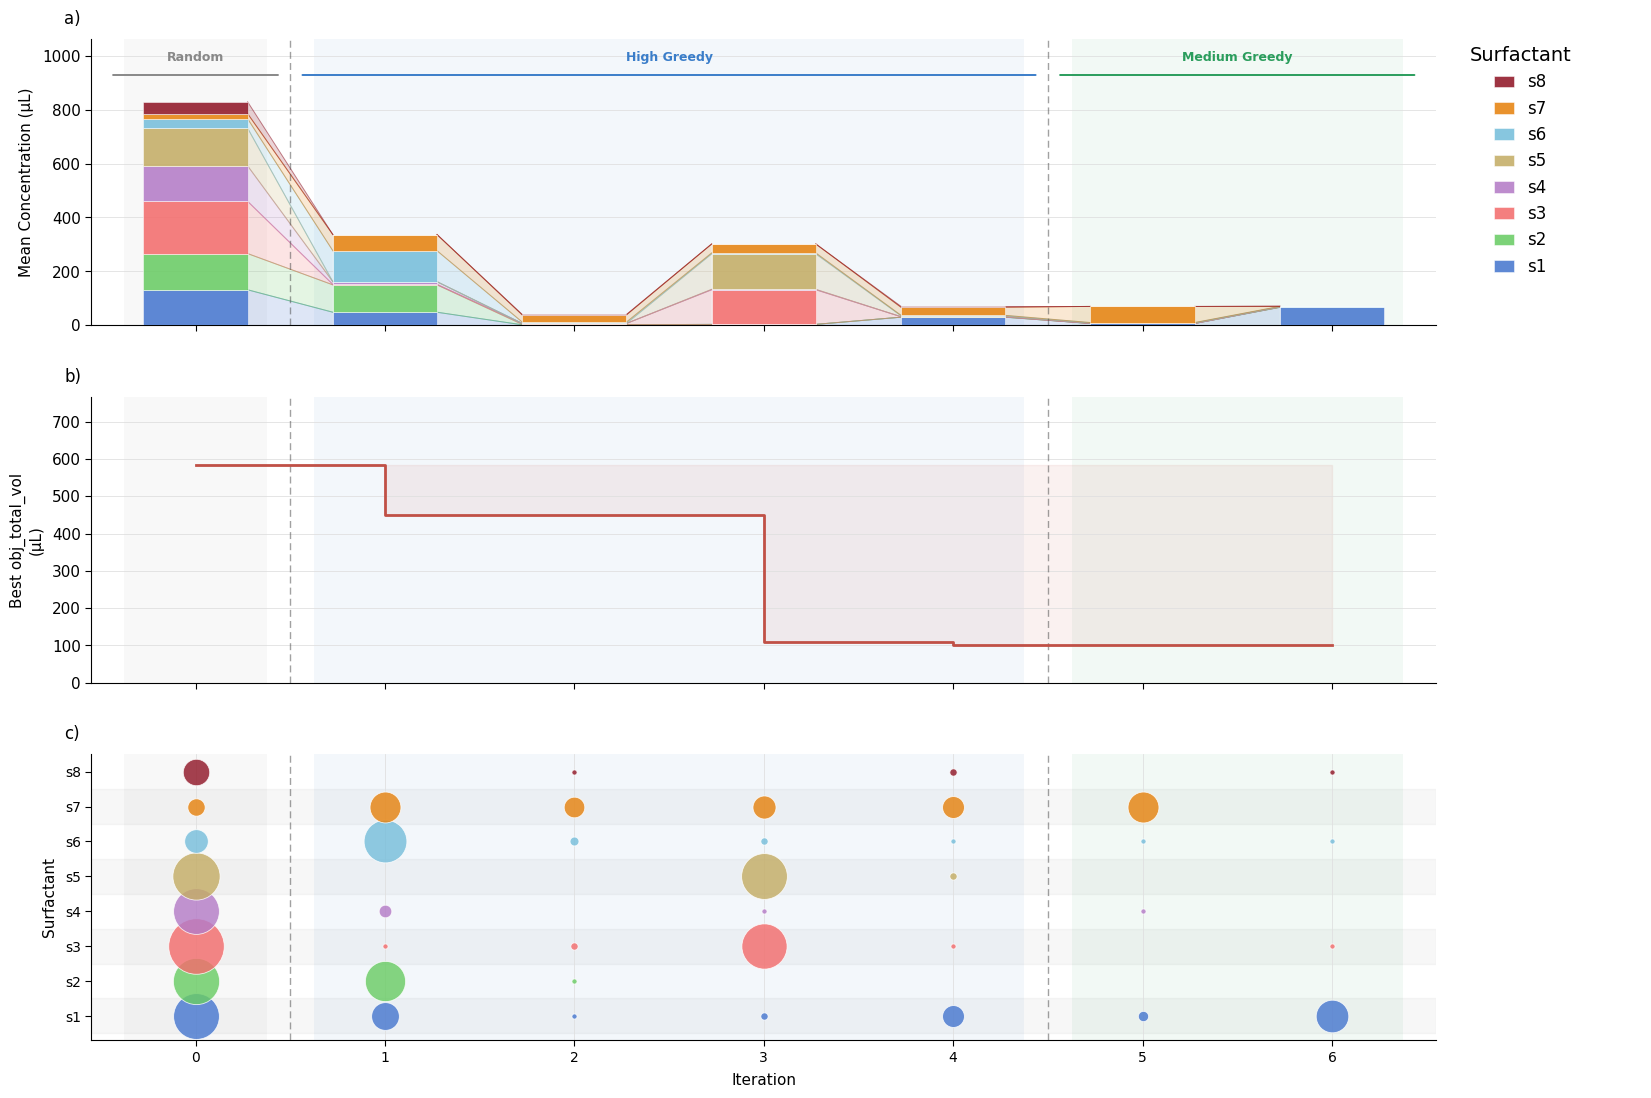

In [16]:
plot_surfactant_combined(df)
